# Topic 18-14: Bode Design Approach

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [3]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

# Bode design Example 1 - VDV 8.16 (18-14)

In [4]:
G = ct.tf(100,np.convolve([1, 1],np.convolve([1, 4],[1, 10])))

wc_des = 9
PMdes = 45

e_ss_desired = 0.1
K_dc_desired = 1/e_ss_desired - 1
w = np.sort(np.append(np.logspace(-2,2,300),wc_des))


### Try 1 - use a gain to solve

In [5]:
K_dc_G = cm.find_Kp(G)
K_required = K_dc_desired/K_dc_G
L = K_required*G
Gcl = ct.feedback(L)
PM_dc,wc_dc,_ = cm.find_PM(w,L)
print(rf"With just a gain of K = {K_required:.2f}, we get: wc = {wc_dc:.2f} rad/s and PM = {PM_dc:.2f} deg")

[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)
[Gclm,Gclp,Gclw] = ct.frequency_response(Gcl,omega=w)

With just a gain of K = 3.60, we get: wc = 4.89 rad/s and PM = 24.83 deg


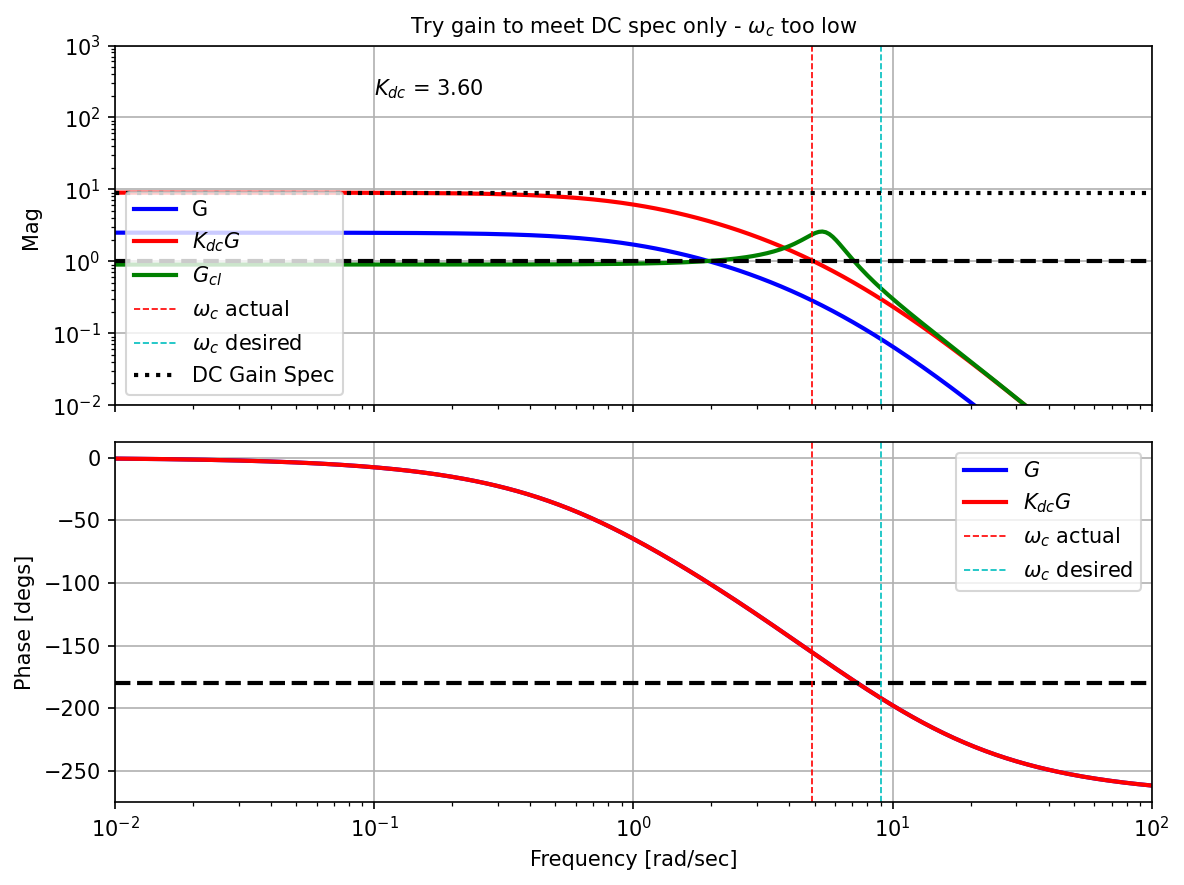

In [6]:
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(Gw,Gm,'b-',label='G')
ax[0].loglog(Gw,K_required*Gm,'r-',label=r'$K_{{dc}} G$')
ax[0].loglog(Gclw,Gclm,'g-',label=r"$G_{cl}$")
ax[0].set_ylim([.01,1000])
ax[0].set_ylabel("Mag ")
ax[0].text(.1,200,rf"$K_{{dc}}$ = {K_required:.2f}")

ax[0].axhline(y=1,c='k',ls="--")
ax[0].axvline(x=wc_dc,c='r',ls="--",lw=0.8,label=r'$\omega_c$ actual')
ax[0].axvline(x=wc_des,c='c',ls="--",label=r'$\omega_c$ desired',lw=0.8)
ax[0].axhline(y=K_dc_desired,c='k',ls=":",label="DC Gain Spec")
ax[0].legend(loc='lower left')

ax[1].semilogx(Gw,cm.wrap_phase_neg(Gp)*cm.r2d,'b-',label=r'$G$')
ax[1].semilogx(Gw,cm.wrap_phase_neg(Gp)*cm.r2d,'r-',label=r'$K_{{dc}} G$')
ax[1].axhline(y=-180,c='k',ls="--")
ax[1].axvline(x=wc_dc,c='r',ls="--",lw=0.8,label=r'$\omega_c$ actual')
ax[1].axvline(x=wc_des,c='c',ls="--",label=r'$\omega_c$ desired',lw=0.8)
ax[1].legend()
ax[1].set_xlim([min(w),max(w)])
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [degs]")
ax[0].set_title(r"Try gain to meet DC spec only - $\omega_c$ too low")
plt.legend()
plt.savefig('./figs/L17_8.pdf',dpi=600)
plt.show()

### Try 2 - set gain to meet wc

With just a gain of K = 12.00, we get: wc = 9.00 rad/s and PM = 348.32 deg


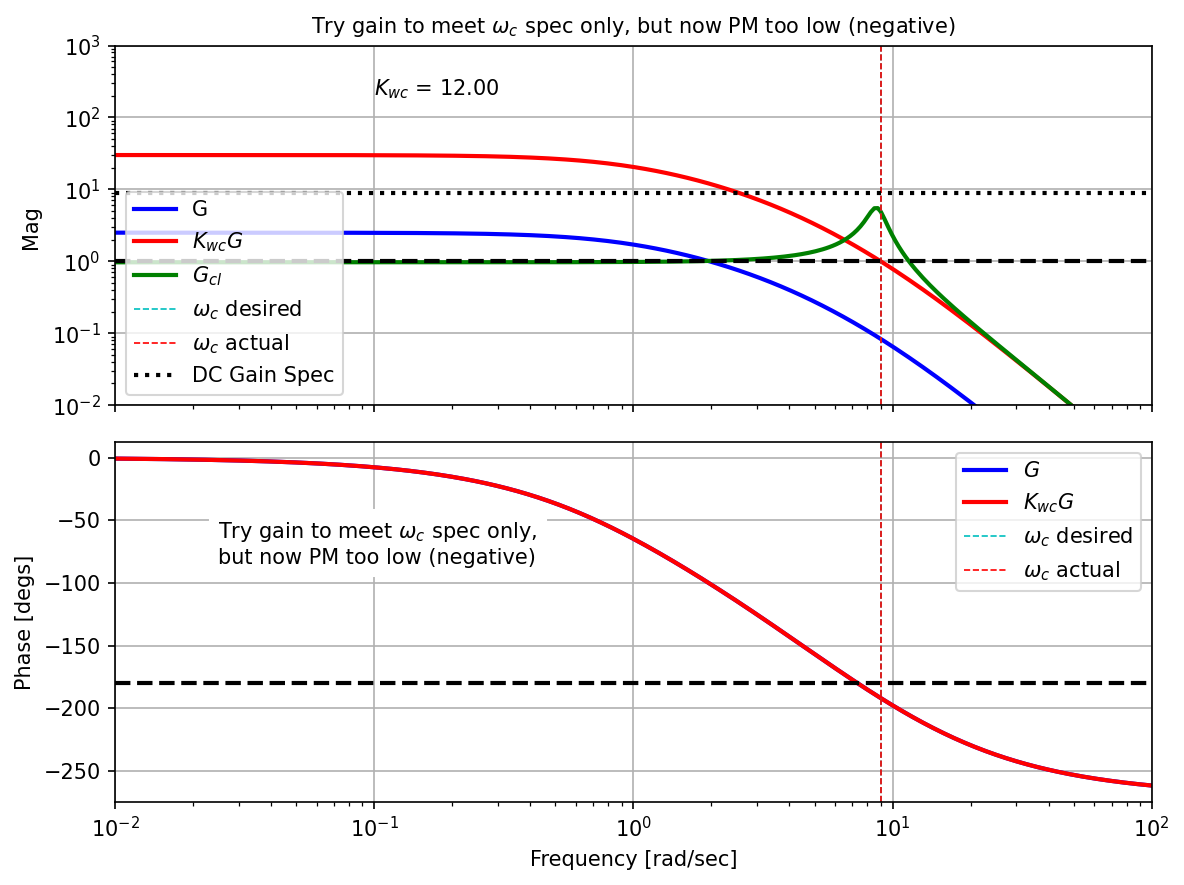

In [7]:
j = complex(0,1)
Gf = G(j*wc_des)
K_wc = 1/np.abs(Gf) # raise plant gain to set w_c
L = K_wc*G
Gcl = ct.feedback(L,1)
[Gclm,Gclp,Gclw] = ct.frequency_response(Gcl,omega=w)
PM_wc,wc_wc,_ = cm.find_PM(w,L)
print(rf"With just a gain of K = {K_wc:.2f}, we get: wc = {wc_wc:.2f} rad/s and PM = {PM_wc:.2f} deg")

fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(Gw,Gm,'b-',label='G')
ax[0].loglog(Gw,K_wc*Gm,'r-',label=r'$K_{{wc}} G$')
ax[0].loglog(Gclw,Gclm,'g-',label=r"$G_{cl}$")
ax[0].axhline(y=1,c='k',ls="--")
ax[0].axvline(x=wc_des,c='c',ls="--",label=r'$\omega_c$ desired',lw=0.8)
ax[0].axvline(x=wc_wc,c='r',ls="--",label=r'$\omega_c$ actual',lw=0.8)
ax[0].axhline(y=K_dc_desired,c='k',ls=":",label='DC Gain Spec')
ax[0].legend(loc='lower left')
ax[0].set_ylim([.01,1000])
ax[0].set_ylabel("Mag ")

ax[1].semilogx(Gw,cm.wrap_phase_neg(Gp)*cm.r2d,'b-',label=r'$G$')
ax[1].semilogx(Gw,cm.wrap_phase_neg(Gp)*cm.r2d,'r-',label=r'$K_{{wc}} G$')
ax[1].axhline(y=-180,c='k',ls="--")
ax[1].axvline(x=wc_des,c='c',ls="--",lw=0.8,label=r'$\omega_c$ desired')
ax[1].axvline(x=wc_wc,c='r',ls="--",lw=0.8,label=r'$\omega_c$ actual')
ax[1].legend()
ax[1].set_xlim([min(w),max(w)])
#ax[1].set_ylim([-270,0])
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [degs]")

def cm_caption(text,ax,xloc=0.025,yloc=-50):
    import textwrap
    wrapped = textwrap.fill(text, width=40)
    """Add a wrapped to a figure."""
    ax.text(xloc, yloc, wrapped, ha='left', va='top', fontsize=10,backgroundcolor='white')
    
msg = r"Try gain to meet $\omega_c$ spec only, but now PM too low (negative)"
cm_caption(msg,ax[1],xloc=0.025,yloc=-50)
ax[0].set_title(msg)
ax[0].text(.1,200,rf"$K_{{wc}}$ = {K_wc:.2f}")
plt.legend()
plt.savefig('./figs/L17_9.pdf',dpi=600)
plt.show()


### Try 3 - add lead 

In [8]:
wc_lead = 12 # higher than required, but try to increase low freq gain
Gc_lead = cm.lead_design(G, wc_des = wc_lead, PMdes = PMdes)
cm.show_tf_latex(Gc_lead, name="G_{c,lead}", show=True, factor=True, sigfigs=2)
L_lead = G*Gc_lead
Gcl_lead = ct.feedback(L_lead,1)

[Gm,Gp,Gw] = ct.frequency_response(G,omega=w)
[Gcm,Gcp,Gcw] = ct.frequency_response(Gc_lead,omega=w)
[Lm,Lp,Lw] = ct.frequency_response(L_lead,omega=w)
[Gclm,Gclp,Gclw] = ct.frequency_response(Gcl_lead,omega=w)

<IPython.core.display.Math object>

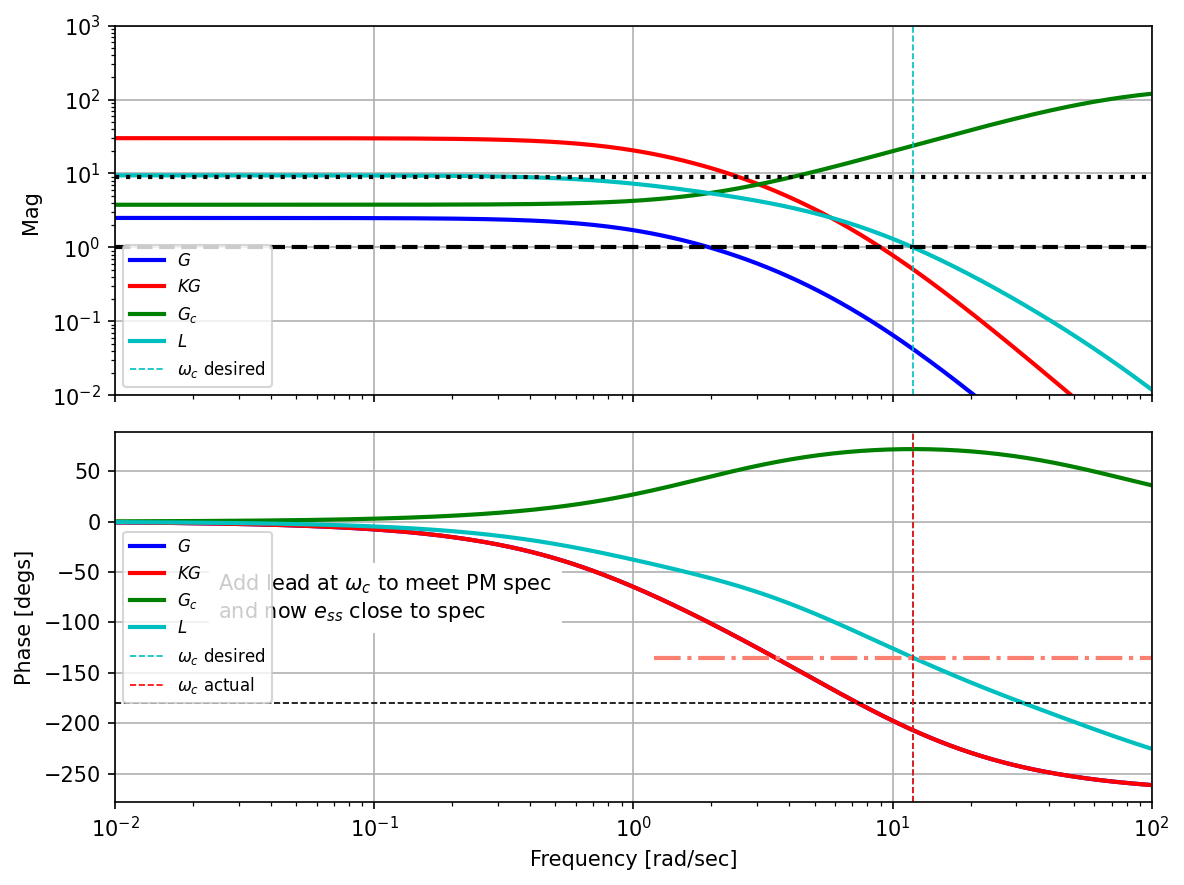

In [9]:
fig, ax = plt.subplots(2,1,figsize=(8, 6),dpi=150,sharex = True)
ax[0].loglog(Gw,Gm,'b-',label=r'$G$')
ax[0].loglog(Gw,K_wc*Gm,'r-',label=r'$KG$')
ax[0].loglog(Gw,Gcm,'g-',label=r'$G_c$')
ax[0].loglog(Gw,Lm,'c-',label=r'$L$')
ax[0].axhline(y=1,c='k',ls="--")
ax[0].axvline(x=wc_lead,c='c',ls="--",lw=0.8,label=r'$\omega_c$ desired')
ax[0].legend(fontsize=8)
ax[0].set_ylim([.01,1000])
ax[0].set_ylabel("Mag ")
ax[0].axhline(y=K_dc_desired,c='k',ls=":")

ax[1].semilogx(Gw,cm.wrap_phase_neg(Gp)*cm.r2d,'b-',label=r'$G$')
ax[1].semilogx(Gw,cm.wrap_phase_neg(Gp)*cm.r2d,'r-',label=r'$KG$')
ax[1].semilogx(Gw,cm.pshift(Gcp)*cm.r2d,'g-',label=r'$G_c$')
ax[1].semilogx(Gw,cm.wrap_phase_neg(Lp)*cm.r2d,'c-',label=r'$L$')
ax[1].axhline(y=-180,c='k',ls="--",lw=0.8)
ax[1].axvline(x=wc_lead,c='c',ls="--",lw=0.8,label=r'$\omega_c$ desired')    

wml,wmh = ax[1].get_xlim()
ax[1].axhline(y=-180+PMdes,
              xmin=(np.log10(wc_lead/10/wml)/np.log10(wmh/wml)),
              xmax=(np.log10(10*wc_lead/wml)/np.log10(wmh/wml)),c='salmon',ls="-.")
ax[1].axvline(x=wc_lead,c='r',ls="--",lw=0.8,label=r'$\omega_c$ actual')
ax[1].legend()
ax[1].set_xlim([min(w),max(w)])
ax[1].set_xlabel("Frequency [rad/sec]")
ax[1].set_ylabel("Phase [degs]")
msg=r"Add lead at $\omega_c$ to meet PM spec and now $e_{ss}$ close to spec"
cm_caption(msg,ax[1],xloc=0.025,yloc=-50)
plt.legend(fontsize=8)
plt.savefig('./figs/L17_10.pdf',dpi=600)
plt.show()

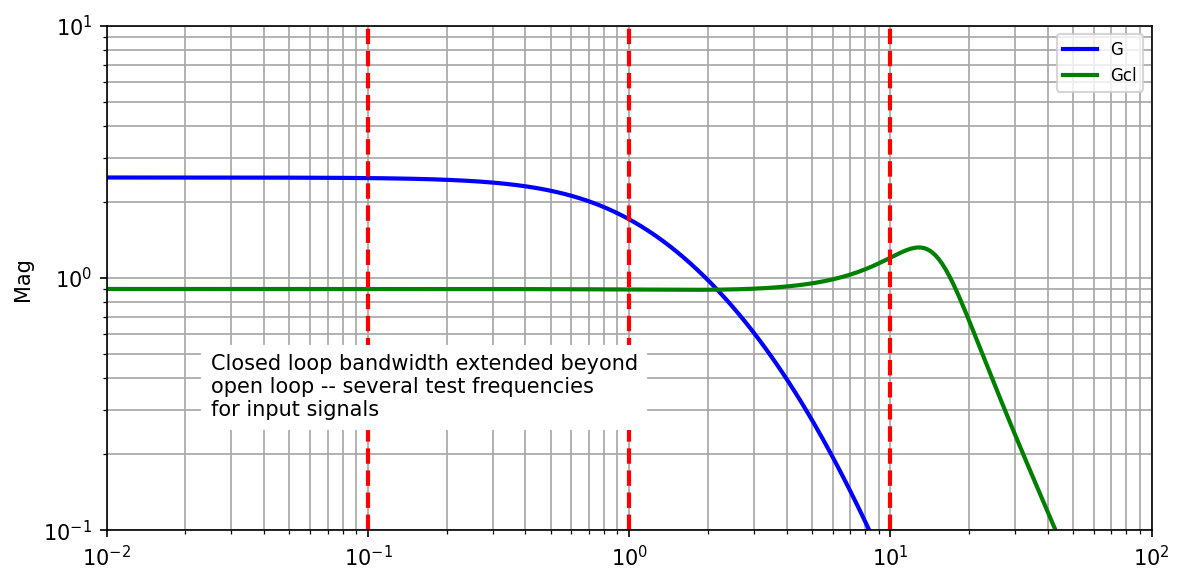

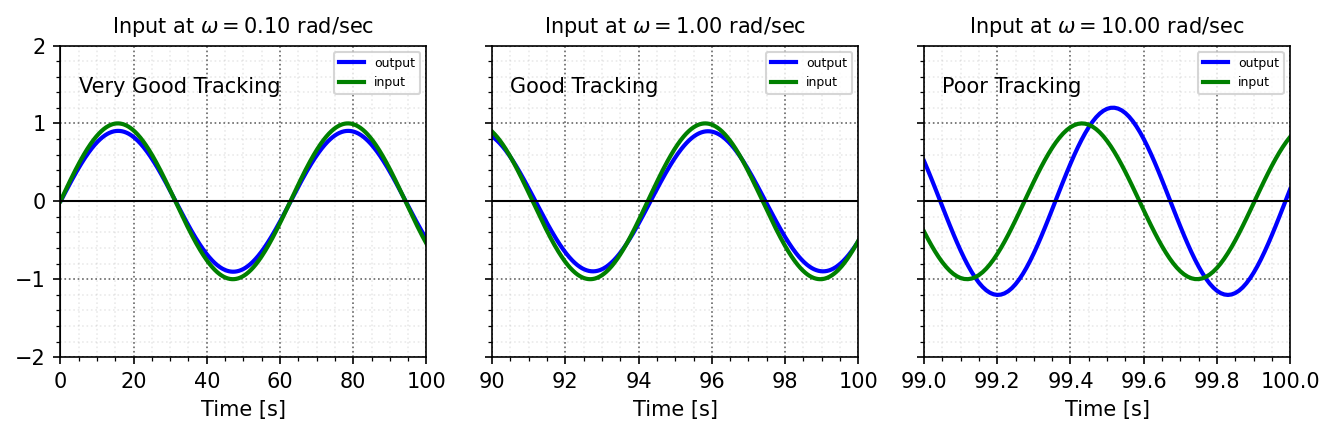

In [10]:
# Add lead 
Tf = 100 # final time
omega = [.1,1,10] # test reponse at these frequencies

[Gclm,Gclp,Gclw] = ct.frequency_response(Gcl_lead,omega=w)

fig, ax = plt.subplots(1,figsize=(8, 4),dpi=150,sharex = True)
ax.loglog(Gw,Gm,'b-',label='G')
ax.loglog(Gclw,Gclm,'g-',label='Gcl')
ax.legend(fontsize=8)
ax.grid(True, which="both", ls="-",color='0.65')
[ax.axvline(x=x,c='r',ls='--') for x in omega]
ax.set_ylim([.1,10])
ax.set_ylabel("Mag ")
msg=r"Closed loop bandwidth extended beyond open loop -- several test frequencies for input signals"
cm_caption(msg,ax,xloc=0.025,yloc=0.5)

plt.legend(fontsize=8)
plt.savefig('./figs/L17_10a.pdf',dpi=600)
plt.show()

t = np.linspace(0,Tf,Tf*100)
Y_sim = {}
U = {}
for kk,ww in enumerate(omega):
    U[kk] = np.sin(ww*t)
    Y_sim[kk],_,_ = cmat.lsim(ct.tf2ss(Gcl_lead),U[kk],t)

memos = ["Very Good Tracking", "Good Tracking", "Poor Tracking"]
fig, ax = plt.subplots(1,3,figsize=(9, 3),dpi=150,sharey=True)
for kk,ww in enumerate(omega):
    ax[kk].plot(t,Y_sim[kk],'b-',label='output')
    ax[kk].plot(t,U[kk],'g-',label='input')
    ax[kk].set_xlabel("Time [s]")
    ax[kk].set_xlim([max(t)-int(1/(ww/omega[2])),max(t)])
    ax[kk].set_ylim([-2,2])
    ax[kk].legend(fontsize=6)
    ax[kk].set_title(r'Input at $\omega=${:.2f} rad/sec'.format(ww))
    ax[kk].text(0.05, 0.9, memos[kk],transform=ax[kk].transAxes,fontsize=10,verticalalignment="top")
    bm.nicegrid(ax[kk])

plt.savefig("./figs/L17_11.pdf", dpi=600)
plt.show()

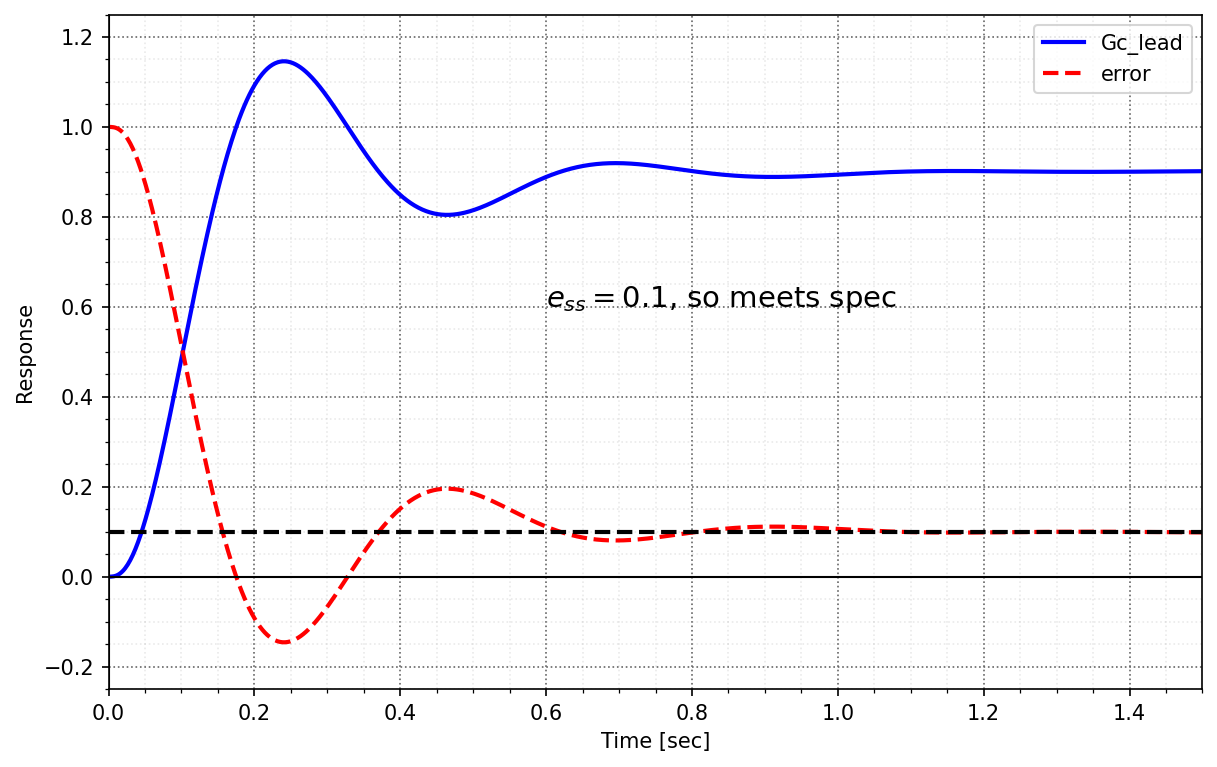

In [11]:
# check SS error in step
Tf = 2
y_lead,t_lead = cmat.step(Gcl_lead,Tf)
fig, ax = plt.subplots(1,figsize=(8, 5),dpi=150,constrained_layout = True)
ax.plot(t_lead,y_lead,'b-',label='Gc_lead')
ax.plot(t_lead,1-y_lead,'r--',label='error')
ax.axhline(y = e_ss_desired,color='k',ls='--')
ax.set_ylim([-0.25,1.25])
ax.set_xlim([0,1.5])
bm.nicegrid(ax)
ax.set_xlabel('Time [sec]')
ax.set_ylabel('Response')
plt.legend()
plt.text(.6, 0.6, r"$e_{ss} = 0.1$, so meets spec", fontsize=14, transform=ax.transData)
plt.savefig("./figs/L17_11a.pdf", dpi=600)
plt.show()